# PCA Analysis of Meteorite Landings

This notebook demonstrates principal component analysis (PCA) on the meteorite landings dataset.  
We will:

1. Load and inspect the data  
2. Select and clean numeric features  
3. Standardize features  
4. Fit PCA and examine loadings  
5. Plot a scree plot  
6. Visualize PC1 vs PC2  
7. Color the PC1–PC2 scatter by meteorite class  


In [1]:
# Cell 2: Imports & Setup
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
# Cell 3: Load & Inspect Data
csv_path = '/Users/pbat/Projects/cmor438/data/meteorite-landings.csv'
df = pd.read_csv(csv_path)

# show first rows, shape, and columns
df.head(), df.shape, df.columns.tolist()


(       name   id nametype     recclass      mass  fall    year    reclat  \
 0    Aachen    1    Valid           L5      21.0  Fell  1880.0  50.77500   
 1    Aarhus    2    Valid           H6     720.0  Fell  1951.0  56.18333   
 2      Abee    6    Valid          EH4  107000.0  Fell  1952.0  54.21667   
 3  Acapulco   10    Valid  Acapulcoite    1914.0  Fell  1976.0  16.88333   
 4   Achiras  370    Valid           L6     780.0  Fell  1902.0 -33.16667   
 
      reclong               GeoLocation  
 0    6.08333     (50.775000, 6.083330)  
 1   10.23333    (56.183330, 10.233330)  
 2 -113.00000  (54.216670, -113.000000)  
 3  -99.90000   (16.883330, -99.900000)  
 4  -64.95000  (-33.166670, -64.950000)  ,
 (45716, 10),
 ['name',
  'id',
  'nametype',
  'recclass',
  'mass',
  'fall',
  'year',
  'reclat',
  'reclong',
  'GeoLocation'])

In [3]:
# Cell 4: Select & Clean Numeric Features
numeric_cols = ['mass', 'reclat', 'reclong']
df_num = df[numeric_cols].dropna()

# how many rows remain?
df_num.shape


(38282, 3)

In [4]:
# Cell 5: Standardize & Fit PCA, then compute loadings
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# compute loadings (feature weights)
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_cols,
    columns=[f'PC{i}' for i in range(1, pca.n_components_+1)]
)
print("Feature loadings for each PC:")
display(loadings)

print("\nExplained variance ratio per PC:")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {ratio:.4f}")


Feature loadings for each PC:


,PC1,PC2,PC3
mass,0.060470,0.998133,-0.008640
reclat,0.705997,-0.036649,0.707266
reclong,-0.705629,0.048868,0.706895



Explained variance ratio per PC:
  PC1: 0.5316
  PC2: 0.3326
  PC3: 0.1358


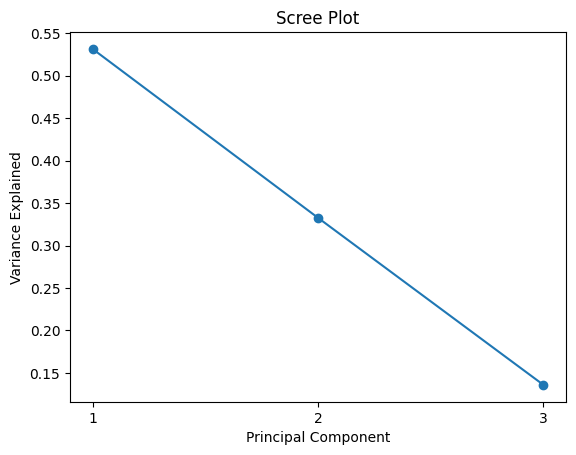

In [5]:
# Cell 6: Plot
plt.figure()
plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker='o'
)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.show()


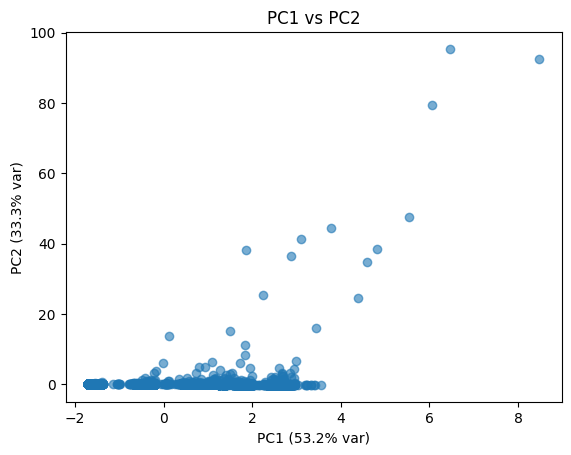

In [6]:
# Cell 7: PC1 vs PC2 Scatter
var1, var2 = pca.explained_variance_ratio_[:2]

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.title('PC1 vs PC2')
plt.xlabel(f'PC1 ({var1:.1%} var)')
plt.ylabel(f'PC2 ({var2:.1%} var)')
plt.show()


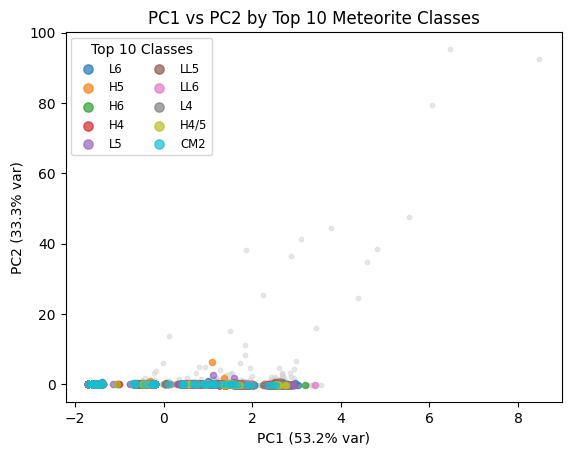

In [ ]:
# Cell 8: PC1 vs PC2 – Top 10 Meteorite Classes Only
# (other classes plotted in light grey without labels)

# 1) Determine the 10 most frequent classes
class_counts = df.loc[df_num.index, 'recclass'].value_counts()
top10 = class_counts.nlargest(10).index.tolist()

# 2) Prepare the DataFrame
df_pcs = pd.DataFrame(
    X_pca[:, :2],
    columns=['PC1', 'PC2'],
    index=df_num.index
)
df_pcs['recclass'] = df.loc[df_num.index, 'recclass']

# 3) Plot “others” in light grey
plt.figure()
others = df_pcs[~df_pcs['recclass'].isin(top10)]
plt.scatter(
    others['PC1'], others['PC2'],
    color='lightgrey', s=10, alpha=0.5,
    label='_nolegend_'
)

# 4) Plot each of the top 10 with a label
for cls in top10:
    subset = df_pcs[df_pcs['recclass'] == cls]
    plt.scatter(
        subset['PC1'], subset['PC2'],
        s=20, alpha=0.7,
        label=cls
    )
plt.legend(title='Top 10 Classes', markerscale=1.5, fontsize='small', loc='best', ncol=2)
plt.title('PC1 vs PC2 by Top 10 Meteorite Classes')
plt.xlabel(f'PC1 ({var1:.1%} var)')
plt.ylabel(f'PC2 ({var2:.1%} var)')
plt.show()
